# 05 — SHAP Explainability

Explain the winning XGBoost model using SHAP (SHapley Additive exPlanations).

| Section | What it shows |
|---------|---------------|
| Global summary | Which features drive predictions most, and in which direction |
| Mean SHAP bar | Ranked feature importance (magnitude) |
| Dependence plots | How top features interact with fraud probability |
| Local explanations | Why the model flagged (or missed) a specific transaction |


In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110

con = duckdb.connect('../data/ecommerce_fraud.duckdb')
df  = con.execute('SELECT * FROM fct_fraud_signals').df()
print(df.shape)

(590540, 22)


## 1. Retrain XGBoost (winning model)

In [2]:
features = [
    'order_amount', 'order_hour', 'account_age_days', 'orders_on_day',
    'customer_avg_order_amount', 'customer_ip_mismatch_count',
    'is_new_customer', 'country_mismatch', 'ip_mismatch', 'high_velocity',
    'payment_method', 'product_category',
]

X = pd.get_dummies(df[features], columns=['payment_method', 'product_category'], drop_first=True)
for c in ['is_new_customer', 'country_mismatch', 'ip_mismatch', 'high_velocity']:
    X[c] = X[c].astype(int)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=200, max_depth=6,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss', random_state=42,
    n_jobs=-1, verbosity=0,
)
model.fit(X_train.values, y_train)
print("Model trained — feature matrix:", X_train.shape)
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

Model trained — feature matrix: (472432, 17)
scale_pos_weight = 27.6


## 2. Compute SHAP values

In [3]:
explainer = shap.TreeExplainer(model)

# Use a 5k sample of the test set — SHAP on 118k rows is slow
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=5000, replace=False)
X_sample = X_test.iloc[sample_idx]

shap_values = explainer.shap_values(X_sample.values)
print("SHAP values shape:", shap_values.shape)
print(f"Expected value (log-odds): {explainer.expected_value:.4f}")

SHAP values shape: (5000, 17)
Expected value (log-odds): -0.0215


## 3. Global summary — beeswarm plot

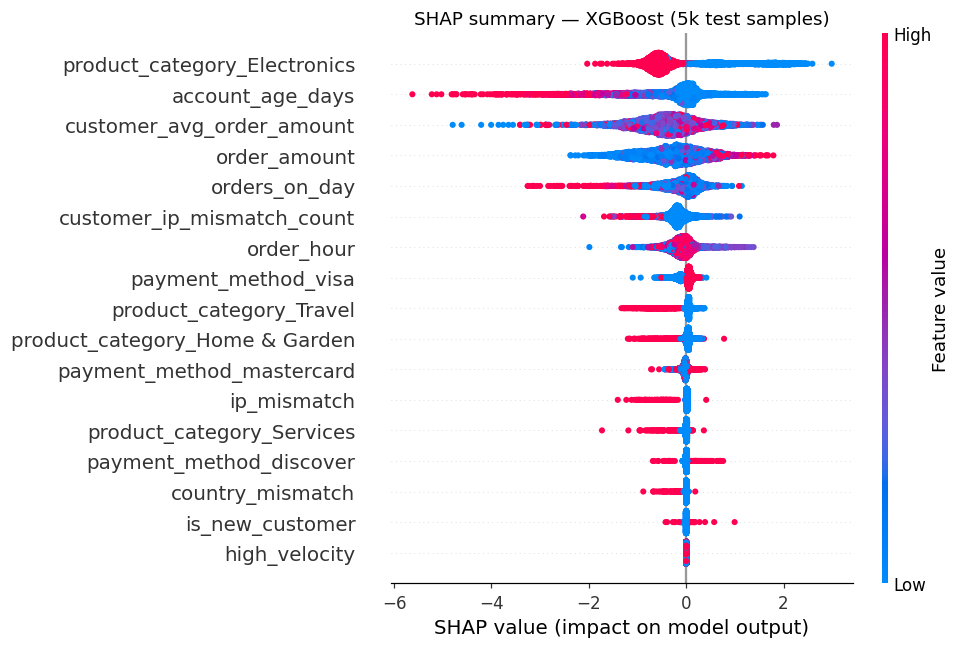

In [4]:
shap.summary_plot(
    shap_values, X_sample,
    feature_names=list(X.columns),
    show=False, plot_size=(9, 6)
)
plt.title('SHAP summary — XGBoost (5k test samples)')
plt.tight_layout()
plt.show()

## 4. Mean absolute SHAP — feature importance bar

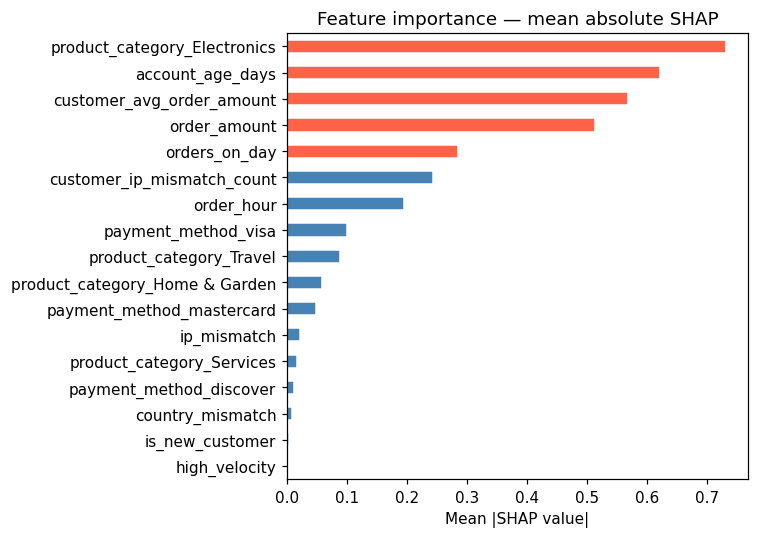

Top 5 features:
product_category_Electronics    0.731978
account_age_days                0.622036
customer_avg_order_amount       0.568238
order_amount                    0.513916
orders_on_day                   0.284794


In [5]:
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=list(X.columns)
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['steelblue' if v < mean_shap.quantile(0.75) else 'tomato'
          for v in mean_shap]
mean_shap.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature importance — mean absolute SHAP')
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(mean_shap.tail(5).sort_values(ascending=False).to_string())

## 5. Dependence plots — top 3 features

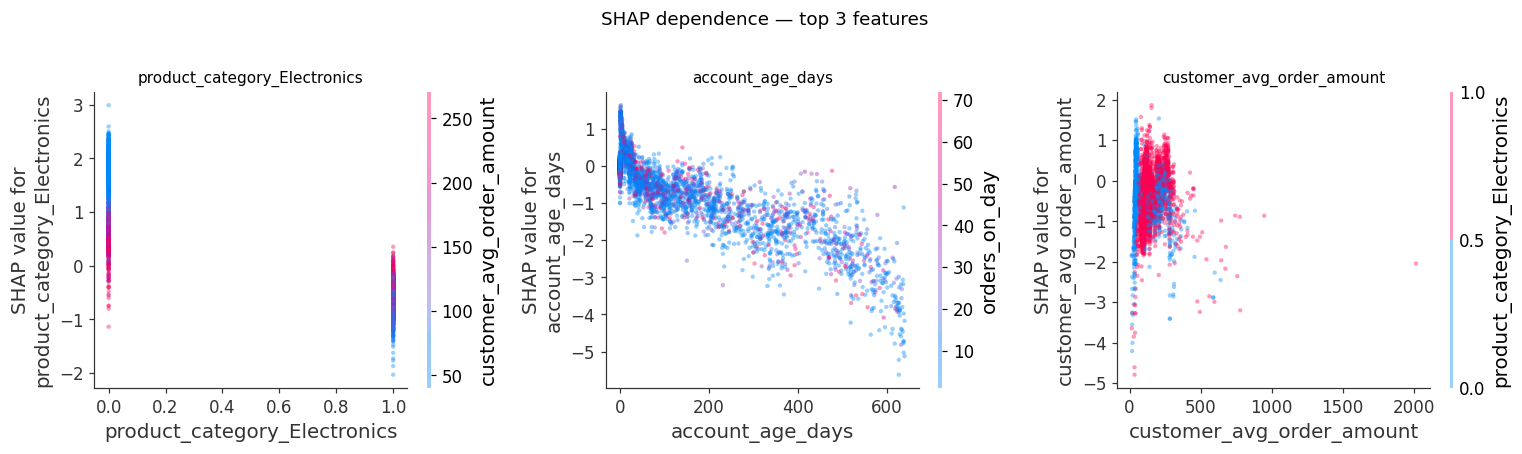

In [6]:
top3 = mean_shap.tail(3).index.tolist()[::-1]
feat_names = list(X.columns)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, top3):
    fidx = feat_names.index(feat)
    shap.dependence_plot(
        fidx, shap_values, X_sample.values,
        feature_names=feat_names,
        ax=ax, show=False, dot_size=8, alpha=0.4
    )
    ax.set_title(feat, fontsize=10)
plt.suptitle('SHAP dependence — top 3 features', y=1.02)
plt.tight_layout()
plt.show()

## 6. Local explanations

In [7]:
y_test_sample  = y_test.iloc[sample_idx].values
y_prob_sample  = model.predict_proba(X_sample.values)[:, 1]
y_pred_sample  = model.predict(X_sample.values)

# True positive: fraud caught
tp_idx = np.where((y_test_sample == 1) & (y_pred_sample == 1))[0]
# False negative: fraud missed
fn_idx = np.where((y_test_sample == 1) & (y_pred_sample == 0))[0]

print(f"True positives in sample:  {len(tp_idx)}")
print(f"False negatives in sample: {len(fn_idx)}")

True positives in sample:  127
False negatives in sample: 39


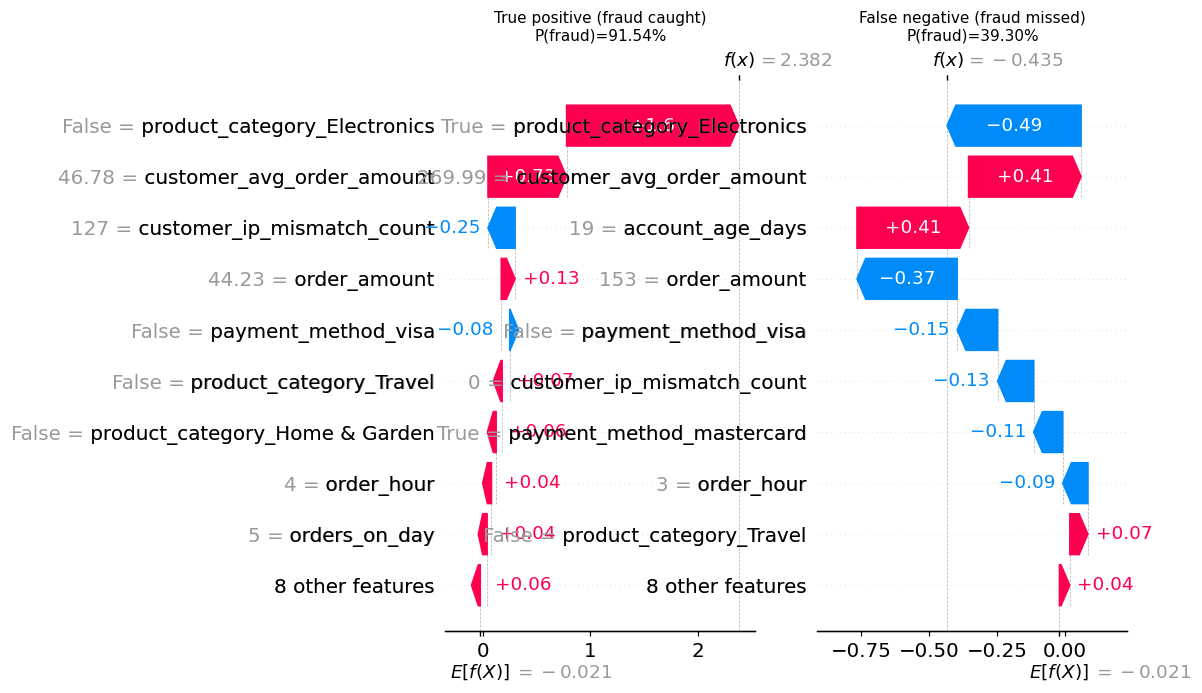

In [8]:
# Waterfall — fraud correctly caught
shap_exp = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(shap_values), explainer.expected_value),
    data=X_sample.values,
    feature_names=list(X.columns)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
shap.plots.waterfall(shap_exp[tp_idx[0]], show=False, max_display=10)
axes[0].set_title(f'True positive (fraud caught)\nP(fraud)={y_prob_sample[tp_idx[0]]:.2%}', fontsize=10)

plt.sca(axes[1])
shap.plots.waterfall(shap_exp[fn_idx[0]], show=False, max_display=10)
axes[1].set_title(f'False negative (fraud missed)\nP(fraud)={y_prob_sample[fn_idx[0]]:.2%}', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Key takeaways

| Finding | Implication |
|---------|-------------|
| Top drivers are numerical features (amount, account age, velocity) | Rule-based thresholds on these features were on the right track |
| Boolean flags (country_mismatch, ip_mismatch) add signal but rank lower | XGBoost learns non-linear interactions between them |
| False negatives tend to have borderline feature values | Threshold tuning or ensemble post-processing could recover them |
